In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.formula.api as smf

In [3]:
data = pd.read_csv('Pooled_biochemdata_June9.csv',sep=',')

In [4]:
data.head() 

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219,10.5,10.5,1.8,1.8,36.1,94.0


In [5]:
data.dtypes

Genes                object
Diagnosis            object
Diag                float64
Patient ID           object
Age                 float64
Gender               object
HBeAg                object
AntiHBe              object
HBV-Viral-load       object
HBV-genotype         object
AFP                  object
AST                 float64
ALT                 float64
WBC                 float64
RBC                 float64
Platelets            object
Total-Bilirubin     float64
TotalBili           float64
Direct-Bilirubin    float64
DirectBili          float64
Albumin             float64
Prothrombin         float64
dtype: object

In [6]:
data['Platelets']=pd.to_numeric(data['Platelets'], errors='coerce')

In [7]:
model = smf.ols(formula="Diag ~ AST+ALT+Platelets+Albumin+Prothrombin+TotalBili+DirectBili",data=data) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Diag   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     26.56
Date:                Mon, 17 Jul 2023   Prob (F-statistic):           2.53e-28
Time:                        14:14:35   Log-Likelihood:                -263.07
No. Observations:                 312   AIC:                             542.1
Df Residuals:                     304   BIC:                             572.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.5156      0.211     26.179      

In [8]:
len(data)

2443

In [7]:
data.isnull().sum()

Genes                  0
Diagnosis             27
Diag                  48
Patient ID             1
Age                   88
Gender               240
HBeAg               2284
AntiHBe             2289
HBV-Viral-load      1272
HBV-genotype        1890
AFP                 1118
AST                  186
ALT                  186
WBC                 1049
RBC                 1053
Platelets           1057
Total-Bilirubin      350
TotalBili            350
Direct-Bilirubin    1179
DirectBili          1179
Albumin             1360
Prothrombin          634
dtype: int64

In [10]:
data['Diagnosis'].value_counts()

Diagnosis
HCC       697
CHB       607
LC        573
HC        240
HCC+LC    176
AHB        68
ASY        55
Name: count, dtype: int64

In [8]:
data['HBV-Viral-load'].value_counts()

HBV-Viral-load
100          35
989000000    17
200           6
12424         4
9440          4
             ..
42363.64      1
1416          1
2280          1
22220         1
2940          1
Name: count, Length: 813, dtype: int64

In [9]:
len(data['Age'])

2443

In [10]:
data['Genes'].value_counts()

Genes
PD1               786
ISG15_SOCS3       690
CISH_FCN2_MICA    588
IRF15             379
Name: count, dtype: int64

In [11]:
data.describe()

,Diag,Age,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
count,2395.000000,2355.000000,2257.000000,2257.000000,1394.000000,1390.000000,1386.000000,2093.000000,2093.000000,1264.000000,1264.000000,1083.000000,1809.000000
mean,4.325261,49.763907,196.926735,212.213868,6.984692,4.654288,191.005411,59.596808,59.596808,43.054842,43.054842,37.285319,72.471089
std,1.366997,13.429711,414.590866,496.539788,2.770070,3.921498,91.021443,108.255117,108.255117,76.301678,76.301678,5.905123,22.320828
min,1.000000,15.000000,3.000000,3.000000,1.800000,1.760000,18.000000,1.200000,1.200000,0.500000,0.500000,17.000000,14.000000
25%,3.000000,40.000000,37.000000,31.000000,5.350000,4.140000,118.000000,13.400000,13.400000,5.600000,5.600000,33.450000,56.000000
50%,4.000000,50.000000,69.000000,55.000000,6.455000,4.600000,185.000000,21.000000,21.000000,11.300000,11.300000,38.100000,75.000000
75%,5.000000,60.000000,161.000000,132.000000,7.900000,5.020000,249.000000,50.500000,50.500000,38.400000,38.400000,41.850000,89.000000
max,7.000000,90.000000,7700.000000,4926.000000,28.650000,148.000000,598.000000,1504.000000,1504.000000,542.700000,542.700000,50.000000,180.000000


#Count each category of columns

In [12]:
data.groupby(['Diagnosis']).size().reset_index()

,Diagnosis,0
0,AHB,68
1,ASY,55
2,CHB,607
3,HC,240
4,HCC,697
5,HCC+LC,176
6,LC,573


In [17]:
data_des = data.describe()

In [19]:
data_des.to_excel('data_des.xlsx')

In [13]:
#Agregate on Diag categories on Age

In [14]:
data.groupby(['Diagnosis','Age']).size().reset_index()

,Diagnosis,Age,0
0,AHB,17.0,1
1,AHB,18.0,2
2,AHB,20.0,2
3,AHB,22.0,1
4,AHB,23.0,2
...,...,...,...
305,LC,77.0,2
306,LC,78.0,2
307,LC,79.0,1
308,LC,81.0,2


# Age distribution between Male and female

In [15]:
data.groupby(['Age','Gender']).size().reset_index()

,Age,Gender,0
0,15.0,Male,2
1,16.0,Male,2
2,17.0,Female,2
3,18.0,Male,6
4,19.0,Female,10
...,...,...,...
127,82.0,Male,1
128,83.0,Male,1
129,84.0,Male,2
130,85.0,Male,1


In [16]:
data.groupby(['Age']).size().reset_index()

,Age,0
0,15.0,3
1,16.0,2
2,17.0,3
3,18.0,7
4,19.0,13
...,...,...
67,82.0,1
68,83.0,1
69,84.0,2
70,85.0,1


In [17]:
dfg = data.groupby(['Age','Gender']).size().reset_index()
dfg['Gender'].value_counts()

Gender
Male      70
Female    62
Name: count, dtype: int64

In [18]:
dfg.head()

,Age,Gender,0
0,15.0,Male,2
1,16.0,Male,2
2,17.0,Female,2
3,18.0,Male,6
4,19.0,Female,10


In [19]:
dfg[0].sum()

2174

In [20]:
for i in dfg['Age']:
    if (dfg.loc[dfg['Gender'] == 'Male'] is 'True'):
        dfg['M']=dfg[0]
    elif (dfg.loc[dfg['Gender'] == 'Female'] is 'True'):
        dfg['F']=dfg[0]

<>:2: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:4: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:2: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:4: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\ikror\AppData\Local\Temp/ipykernel_20428/3320333292.py:2: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if (dfg.loc[dfg['Gender'] == 'Male'] is 'True'):
C:\Users\ikror\AppData\Local\Temp/ipykernel_20428/3320333292.py:4: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif (dfg.loc[dfg['Gender'] == 'Female'] is 'True'):


In [21]:
dfg.head()

,Age,Gender,0
0,15.0,Male,2
1,16.0,Male,2
2,17.0,Female,2
3,18.0,Male,6
4,19.0,Female,10


In [22]:
type(dfg)

pandas.core.frame.DataFrame

In [23]:
dfg.describe()

,Age,0
count,132.000000,132.000000
mean,50.143939,16.469697
std,19.665187,16.577571
min,15.000000,1.000000
25%,33.750000,4.000000
50%,50.000000,10.500000
75%,66.250000,26.000000
max,90.000000,67.000000


In [24]:
dfg.isnull().sum()

Age       0
Gender    0
0         0
dtype: int64

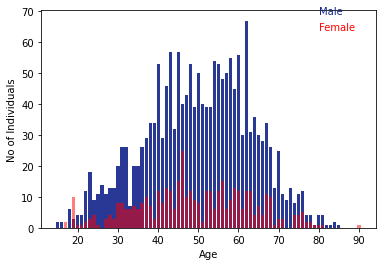

In [25]:
p1 = plt.bar(dfg.loc[dfg['Gender'] == 'Male']['Age']
             ,dfg.loc[dfg['Gender'] == 'Male'][0]
             ,alpha=0.9,color='#128',label='Male')
plt.text(80, 70, 'Male', va='center', color = '#128')

p2 = plt.bar(dfg.loc[dfg['Gender'] == 'Female']['Age']
             ,dfg.loc[dfg['Gender'] == 'Female'][0]
            , alpha=0.5,color='red')
plt.text(80, 65, 'Female', va='center', color = 'red')
plt.xlabel ('Age')
plt.ylabel('No of Individuals')

plt.savefig('Age.png')


In [26]:
dfg.isnull().sum()

Age       0
Gender    0
0         0
dtype: int64

In [27]:
dfg_new=dfg.dropna()

<AxesSubplot:xlabel='Age', ylabel='Density'>

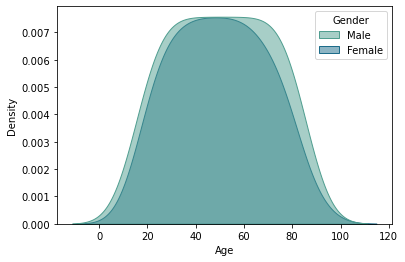

In [28]:
sns.kdeplot(data=dfg, x="Age", hue="Gender",fill=True,alpha=0.5,palette="crest")


<AxesSubplot:xlabel='Age', ylabel='Density'>

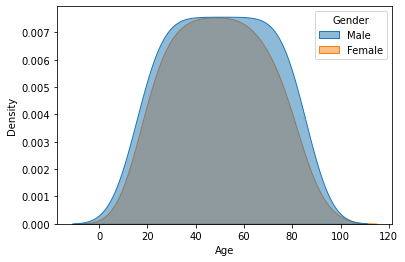

In [29]:
sns.kdeplot(data=dfg, x="Age", hue="Gender",fill=True,alpha=0.5)


In [30]:
data.isnull().sum()

Genes                  0
Diagnosis             27
Diag                  48
Patient ID             1
Age                   88
Gender               240
HBeAg               2284
AntiHBe             2289
HBV-Viral-load      1272
HBV-genotype        1890
AFP                 1118
AST                  186
ALT                  186
WBC                 1049
RBC                 1053
Platelets           1057
Total-Bilirubin      350
TotalBili            350
Direct-Bilirubin    1179
DirectBili          1179
Albumin             1360
Prothrombin          634
dtype: int64

Population pyramid

In [31]:
dfg['Male']=dfg.loc[dfg['Gender'] == 'Male'][0]
dfg['Male']=dfg['Male'].fillna(0)
dfg['Female']=dfg.loc[dfg['Gender'] == 'Female'][0]*-1
dfg['Female']=dfg['Female'].fillna(0)

In [32]:
dfg['Age'].max()

90.0

In [33]:
dfg['Age'].min()

15.0

In [34]:
dfg['Male']=dfg.loc[dfg['Gender'] == 'Male'][0]
dfg['Male']=dfg['Male'].fillna(0)

In [35]:
dfg['Female']=dfg.loc[dfg['Gender'] == 'Female'][0]*-1
dfg['Female']=dfg['Female'].fillna(0)

In [36]:
dfg.head()

,Age,Gender,0,Male,Female
0,15.0,Male,2,2.0,0.0
1,16.0,Male,2,2.0,0.0
2,17.0,Female,2,0.0,-2.0
3,18.0,Male,6,6.0,0.0
4,19.0,Female,10,0.0,-10.0


In [37]:
df=dfg[['Age','Male']]

In [39]:
df1=dfg[['Age','Female']]

In [41]:
df.drop(df.loc[df['Male']==0].index, inplace=True)

C:\Users\ikror\AppData\Local\Temp/ipykernel_20428/2170513954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df.loc[df['Male']==0].index, inplace=True)


In [42]:
len(df)

70

In [43]:
df1.drop(df1.loc[df1['Female']==0].index, inplace=True)

C:\Users\ikror\AppData\Local\Temp/ipykernel_20428/2321680682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(df1.loc[df1['Female']==0].index, inplace=True)


In [44]:
len(df1)

62

In [45]:
df2=df.merge(df1,how='outer',on='Age')

In [46]:
len(df2)


72

In [47]:
df2.head()

,Age,Male,Female
0,15.0,2.0,NaN
1,16.0,2.0,NaN
2,18.0,6.0,NaN
3,19.0,3.0,-10.0
4,20.0,4.0,-1.0


In [48]:
df2['Male']=df2['Male'].fillna(0)

In [49]:
df2['Female']=df2['Female'].fillna(0)

In [50]:
df2.head()

,Age,Male,Female
0,15.0,2.0,0.0
1,16.0,2.0,0.0
2,18.0,6.0,0.0
3,19.0,3.0,-10.0
4,20.0,4.0,-1.0


In [51]:
age=df['Age']

In [52]:
len(age)

70

In [53]:
df2['Male'].max()

67.0

In [54]:
df2['Male'].min()

0.0

In [55]:
df2['Female'].max()

0.0

In [56]:
df2['Female'].min()

-25.0

In [57]:
X=len(df2)

In [58]:
y = range(0, len(df2))

In [59]:
y

range(0, 72)

In [60]:
#y = range(0, len(df2))
y=df2['Age']
x_male = df2['Male']
x_female = df2['Female']

In [61]:
df2

,Age,Male,Female
0,15.0,2.0,0.0
1,16.0,2.0,0.0
2,18.0,6.0,0.0
3,19.0,3.0,-10.0
4,20.0,4.0,-1.0
...,...,...,...
67,83.0,1.0,0.0
68,84.0,2.0,0.0
69,85.0,1.0,0.0
70,17.0,0.0,-2.0


In [62]:
x_male

0     2.0
1     2.0
2     6.0
3     3.0
4     4.0
     ... 
67    1.0
68    2.0
69    1.0
70    0.0
71    0.0
Name: Male, Length: 72, dtype: float64

In [63]:
x_female 

0      0.0
1      0.0
2      0.0
3    -10.0
4     -1.0
      ... 
67     0.0
68     0.0
69     0.0
70    -2.0
71    -1.0
Name: Female, Length: 72, dtype: float64

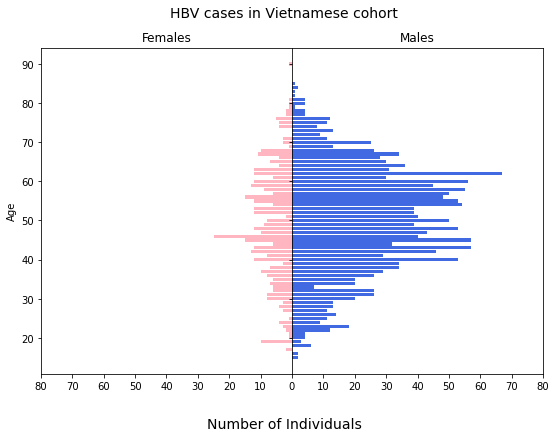

In [64]:
fig, axes = plt.subplots(ncols=2,sharey=True, figsize=(9, 6))
axes[0].set(ylabel='Age')
plt.figtext(.5,.95,"HBV cases in Vietnamese cohort", fontsize=14, ha='center')
plt.figtext(.5,0,"Number of Individuals", fontsize=14, ha='center')
axes[0].barh(y, x_female, color='lightpink')
axes[0].set(title='Females')
axes[1].barh(y, x_male, color='royalblue')
axes[1].set(title='Males')
axes[0].set(xticks=[-80,-70,-60,-50,-40,-30,-20,-10])
axes[0].set(xticklabels=[80,70,60,50,40,30,20,10])
axes[1].set(xticks=[80,70,60,50,40,30,20,10,0])
axes[1].set(xticklabels=[80,70,60,50,40,30,20,10,0])
plt.subplots_adjust(wspace=0, hspace=0)
#plt.show()
plt.savefig('Age_Gender.png')

In [65]:
#df2.to_excel("ageGender.xlsx", index=False)

# Age and Diagnosis (AHB,CHB,LC,HCC)

In [65]:
dfd = data.groupby(['Diagnosis','Age']).size().reset_index()
dfd['Diagnosis'].value_counts()

Diagnosis
CHB       62
HCC       62
LC        61
HC        40
HCC+LC    39
AHB       26
ASY       20
Name: count, dtype: int64

In [66]:
dfd.head()

,Diagnosis,Age,0
0,AHB,17.0,1
1,AHB,18.0,2
2,AHB,20.0,2
3,AHB,22.0,1
4,AHB,23.0,2


In [67]:
dfd.drop(dfd[dfd['Diagnosis']=='bowel cancer'].index, inplace=True)

In [68]:
dfd.drop(dfd[dfd['Diagnosis']=='HC'].index, inplace=True)

In [69]:
dfd.value_counts()

Diagnosis  Age   0
AHB        17.0  1    1
HCC+LC     52.0  1    1
           33.0  1    1
           34.0  1    1
           37.0  2    1
                     ..
CHB        67.0  6    1
           69.0  2    1
           70.0  4    1
           71.0  3    1
LC         84.0  2    1
Name: count, Length: 270, dtype: int64

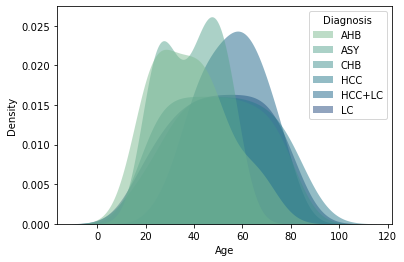

In [70]:
sns.kdeplot(
   data=dfd, x="Age", hue="Diagnosis",
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,
)
plt.savefig('Age_Diag_density.png')

In [71]:
dfd['ASY'] = dfd.loc[dfd['Diagnosis'] == 'ASY'][0]
dfd['ASY']=dfd['ASY'].fillna(0)            
dfd['AHB'] = dfd.loc[dfd['Diagnosis'] == 'AHB'][0]
dfd['AHB']=dfd['AHB'].fillna(0)              
dfd['CHB'] = dfd.loc[dfd['Diagnosis'] == 'CHB'][0]
dfd['CHB']=dfd['CHB'].fillna(0)           
dfd['LC'] = dfd.loc[dfd['Diagnosis'] == 'LC'][0]
dfd['LC']=dfd['LC'].fillna(0)            
dfd['HCC'] = dfd.loc[dfd['Diagnosis'] == 'HCC'][0]
dfd['HCC']=dfd['HCC'].fillna(0)  
dfd['HCC_LC'] = dfd.loc[dfd['Diagnosis'] == 'HCC+LC'][0]
dfd['HCC_LC']=dfd['HCC_LC'].fillna(0) 
X = dfd['Age']

In [72]:
ASY=dfd['ASY']
AHB=dfd['ASY']
CHB=dfd['CHB']
LC=dfd['LC']
HCC=dfd['HCC']
HCC_LC=dfd['HCC_LC']

In [73]:
#dfd.to_excel("ageDiagnosis.xlsx", index=False)

In [74]:
dfd.head()

,Diagnosis,Age,0,ASY,AHB,CHB,LC,HCC,HCC_LC
0,AHB,17.0,1,0.0,1.0,0.0,0.0,0.0,0.0
1,AHB,18.0,2,0.0,2.0,0.0,0.0,0.0,0.0
2,AHB,20.0,2,0.0,2.0,0.0,0.0,0.0,0.0
3,AHB,22.0,1,0.0,1.0,0.0,0.0,0.0,0.0
4,AHB,23.0,2,0.0,2.0,0.0,0.0,0.0,0.0


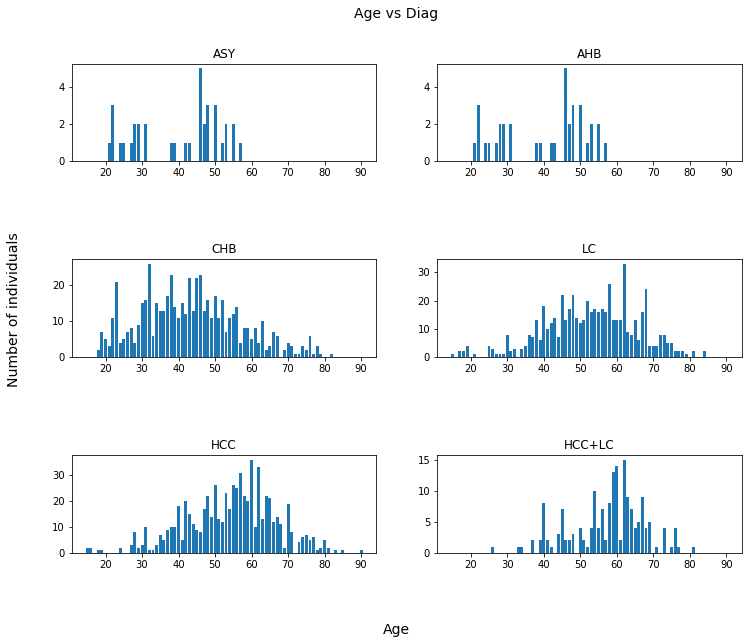

In [75]:
figure, axis = plt.subplots(nrows=3, ncols=2,figsize=(12, 9))
plt.figtext(.5,.95,"Age vs Diag", fontsize=14, ha='center')
plt.figtext(.5,0,"Age", fontsize=14, ha='center')
plt.figtext(0.05,.5,"Number of individuals", fontsize=14, rotation='vertical', va='center')

axis[0, 0].bar(X, ASY)
axis[0, 0].set_title("ASY",fontsize=12)
  

axis[0, 1].bar(X, AHB)
axis[0, 1].set_title("AHB", fontsize=12)

axis[1, 0].bar(X, CHB)
axis[1, 0].set_title("CHB", fontsize=12)
  

axis[1, 1].bar(X, LC)
axis[1, 1].set_title("LC", fontsize=12)

axis[2, 0].bar(X, HCC)
axis[2, 0].set_title("HCC", fontsize=12)

axis[2, 1].bar(X, HCC_LC)
axis[2, 1].set_title("HCC+LC", fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=1)

#plt.show()

plt.savefig('Age_Diag.png',bbox_inches='tight')

Gender and Diagnosis

In [76]:
data.head()

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101.0,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104.0,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268.0,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219.0,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219.0,10.5,10.5,1.8,1.8,36.1,94.0


In [77]:
dfdg=data.groupby(['Diagnosis','Gender']).size().reset_index()

In [78]:
dfdg.drop(dfdg[dfdg['Diagnosis']=='bowel cancer'].index, inplace=True)

In [79]:
dfdg.drop(dfdg[dfdg['Diagnosis']=='HC'].index, inplace=True)

In [80]:
dfdg.value_counts()

Diagnosis  Gender  0  
AHB        Female  2      1
           Male    37     1
ASY        Female  8      1
           Male    46     1
CHB        Female  118    1
           Male    427    1
HCC        Female  79     1
           Male    540    1
HCC+LC     Female  9      1
           Male    167    1
LC         Female  97     1
           Male    427    1
Name: count, dtype: int64

In [81]:
dfdg.head(15)

,Diagnosis,Gender,0
0,AHB,Female,2
1,AHB,Male,37
2,ASY,Female,8
3,ASY,Male,46
4,CHB,Female,118
5,CHB,Male,427
8,HCC,Female,79
9,HCC,Male,540
10,HCC+LC,Female,9
11,HCC+LC,Male,167


In [82]:
len(dfdg)

12

In [83]:
dfdg

,Diagnosis,Gender,0
0,AHB,Female,2
1,AHB,Male,37
2,ASY,Female,8
3,ASY,Male,46
4,CHB,Female,118
5,CHB,Male,427
8,HCC,Female,79
9,HCC,Male,540
10,HCC+LC,Female,9
11,HCC+LC,Male,167


In [84]:
male_diag=dfdg.loc[dfdg['Gender'] == 'Male']['Diagnosis']

In [85]:
male_diag = np.arange(len(male_diag))

In [86]:
male_diag

array([0, 1, 2, 3, 4, 5])

In [87]:
diag=dfdg.loc[dfdg['Gender'] == 'Male']['Diagnosis']

In [88]:
female_diag=dfdg.loc[dfdg['Gender'] == 'Female']['Diagnosis']

In [89]:
female_diag = np.arange(len(female_diag))

In [90]:
female_diag

array([0, 1, 2, 3, 4, 5])

In [91]:
female_diag

array([0, 1, 2, 3, 4, 5])

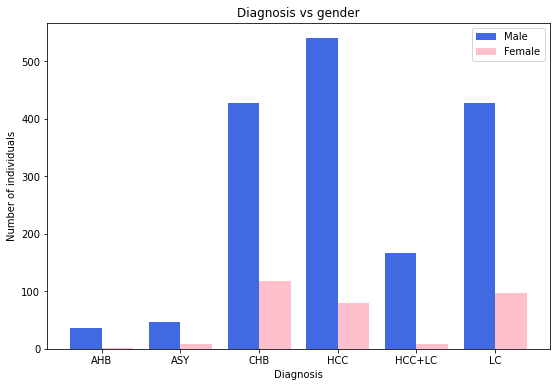

In [92]:
fig, axes = plt.subplots(figsize=(9, 6))
p1=plt.bar(male_diag - 0.2, dfdg.loc[dfdg['Gender'] == 'Male'][0], 0.4, color='royalblue', label='Male',align='center')

p2=plt.bar(female_diag + 0.2, dfdg.loc[dfdg['Gender'] == 'Female'][0], 0.4, color='pink', label='Female', align='center')

plt.xticks(male_diag, diag)
plt.legend( (p1, p2), ('Male', 'Female') )
plt.xlabel("Diagnosis")
plt.ylabel("Number of individuals")
plt.title('Diagnosis vs gender')
plt.savefig('Diag_Gender.png')

# Viral load and Diagnosis (AHB,CHB,LC,HCC)

In [93]:
dfvl = data.groupby(['Diagnosis','HBV-Viral-load']).size().reset_index()
dfvl['Diagnosis'].value_counts()

Diagnosis
CHB       297
LC        198
HCC       184
HCC+LC     64
ASY        54
AHB        44
Name: count, dtype: int64

In [94]:
dfvl.drop(dfvl[dfvl['HBV-Viral-load']=='m'].index, inplace=True)

In [95]:
dfvl.drop(dfvl[dfvl['HBV-Viral-load']=='NA'].index, inplace=True)

In [96]:
dfvl['HBV-Viral-load'].max()

'99500'

In [97]:
dfvl.head()

,Diagnosis,HBV-Viral-load,0
0,AHB,11425,1
1,AHB,11944.8,1
2,AHB,14239.8,1
3,AHB,14908.5,1
4,AHB,153944,1


In [98]:
len(dfvl)

840

In [99]:
dfvl.isnull().sum()

Diagnosis         0
HBV-Viral-load    0
0                 0
dtype: int64

In [100]:
dfvl['HBV-Viral-load'] = pd.to_numeric(dfvl["HBV-Viral-load"])
#sns.violinplot(data=dfvl, x='Diagnosis', y='HBV-Viral-load')

<function matplotlib.pyplot.show(close=None, block=None)>

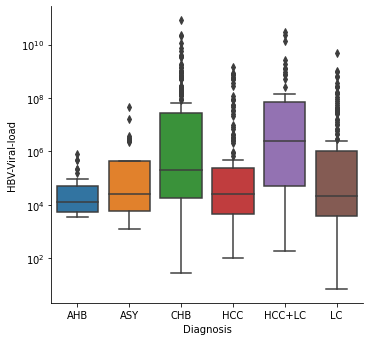

In [101]:
g = sns.catplot(x="Diagnosis", y="HBV-Viral-load", data=dfvl, kind="box")
g.set(yscale="log")
plt.show

In [102]:
medians = dfvl.groupby(['Diagnosis'])['HBV-Viral-load'].median()

In [103]:
medians

Diagnosis
AHB         13092.3
ASY         25581.0
CHB        198000.0
HCC         25572.0
HCC+LC    2435000.0
LC          22563.9
Name: HBV-Viral-load, dtype: float64

(array([835.,   4.,   0.,   0.,   1.]),
 array([7.000e+00, 1.672e+10, 3.344e+10, 5.016e+10, 6.688e+10, 8.360e+10]),
 <BarContainer object of 5 artists>)

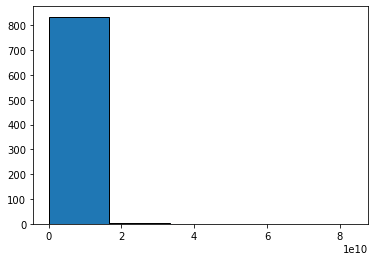

In [104]:
plt.hist(dfvl['HBV-Viral-load'], edgecolor='black', bins=5)

In [105]:
import statsmodels.api as sm

<function matplotlib.pyplot.show(close=None, block=None)>

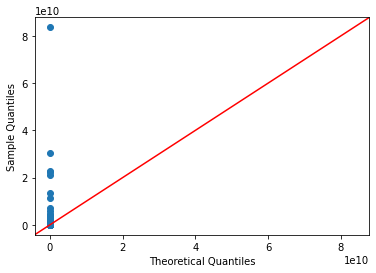

In [106]:
fig = sm.qqplot(dfvl['HBV-Viral-load'], line='45')
plt.show

In [104]:
#g=sns.catplot(data=dfvl, x="Diagnosis", y="HBV-Viral-load", kind="violin")
#g.set(yscale="log")

# Kruskal-Wallis analysis

In [107]:
from scipy import stats

In [108]:
y='HBV-Viral-load'

In [109]:
#Define a function for the Kruskal-Wallis test
def extrDiag(x,y):
    HCC=x.loc[x['Diagnosis']=='HCC',y]
    CHB=x.loc[x['Diagnosis']=='CHB',y]
    LC=x.loc[x['Diagnosis']=='LC',y]
    HCCLC=x.loc[x['Diagnosis']=='HCC+LC',y]
    AHB=x.loc[x['Diagnosis']=='AHB',y]
    ASY=x.loc[x['Diagnosis']=='ASY',y]
    return (stats.kruskal(HCC,CHB,LC,HCCLC,AHB,ASY))

In [110]:
#Call the function with the corresponding dataframe
extrDiag(dfvl,y)

KruskalResult(statistic=77.49617850123141, pvalue=2.8012965027410836e-15)

In [111]:
data = data[data['HBV-Viral-load'] != 'm']

In [112]:
data = data[data['Diagnosis'] != 'bowel cancer']

In [113]:
data.head()

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101.0,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104.0,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268.0,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219.0,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219.0,10.5,10.5,1.8,1.8,36.1,94.0


In [114]:
data['HBV-Viral-load'] = pd.to_numeric(data["HBV-Viral-load"])

<Figure size 1800x1080 with 0 Axes>

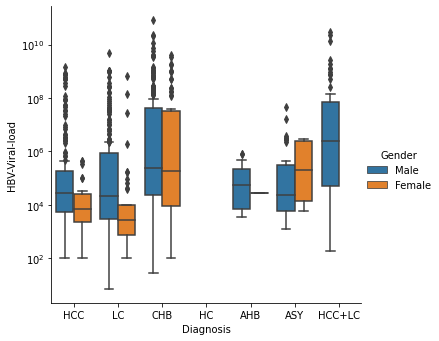

In [115]:
plt.figure(figsize=(25,15))
g=sns.catplot(data=data, x="Diagnosis", y="HBV-Viral-load",hue="Gender",kind="box")
g.set(yscale="log")

# Correlation between Viral load and Laboratory parameters (AST,ALT,AFP...)

In [115]:
#pip install --upgrade pingouin

In [116]:
#import pingouin as pg

In [116]:
data.head()

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101.0,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104.0,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268.0,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219.0,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219.0,10.5,10.5,1.8,1.8,36.1,94.0


In [117]:
data.isnull().sum()

Genes                  0
Diagnosis             27
Diag                  48
Patient ID             1
Age                   88
Gender               240
HBeAg               2284
AntiHBe             2289
HBV-Viral-load      1272
HBV-genotype        1889
AFP                 1118
AST                  186
ALT                  186
WBC                 1049
RBC                 1053
Platelets           1057
Total-Bilirubin      350
TotalBili            350
Direct-Bilirubin    1179
DirectBili          1179
Albumin             1360
Prothrombin          634
dtype: int64

In [118]:
dfAST = data.groupby(['Diagnosis','AST']).size().reset_index()
dfAST['Diagnosis'].value_counts()

Diagnosis
CHB       312
LC        210
HCC       200
HCC+LC     99
AHB        45
HC         29
Name: count, dtype: int64

In [119]:
#dfAST.to_excel('AST.xlsx')

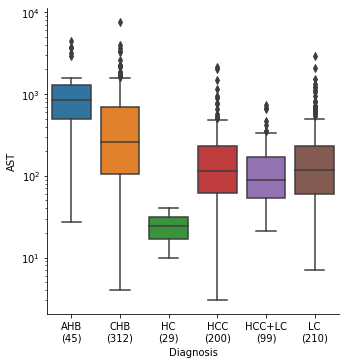

In [120]:
g=sns.catplot(data=dfAST, x="Diagnosis", y="AST", kind="box")
g.set(yscale="log")
g.set_axis_labels("Diagnosis", "AST")
#cnts = dict(dfAST['Diagnosis'].value_counts())
cnts={'AHB': 45,'CHB': 312, 'HC': 29, 'HCC': 200, 'HCC+LC': 99, 'LC': 210}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('AST.png',bbox_inches='tight')

In [121]:
Medians=dfAST.groupby(['Diagnosis'])['AST'].median()

In [122]:
Medians

Diagnosis
AHB       854.0
CHB       257.5
HC         24.0
HCC       114.5
HCC+LC     90.0
LC        117.5
Name: AST, dtype: float64

(array([862.,  24.,   8.,   0.,   1.]),
 array([3.0000e+00, 1.5424e+03, 3.0818e+03, 4.6212e+03, 6.1606e+03,
        7.7000e+03]),
 <BarContainer object of 5 artists>)

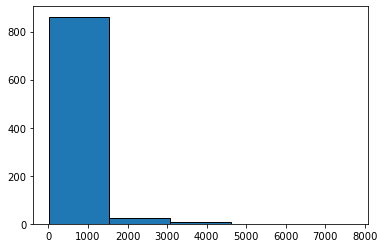

In [123]:
plt.hist(dfAST['AST'],edgecolor='black',bins=5)

In [124]:
dfALT = data.groupby(['Diagnosis','ALT']).size().reset_index()
dfALT['Diagnosis'].value_counts()

Diagnosis
CHB       328
LC        182
HCC       168
HCC+LC     91
AHB        46
HC         35
Name: count, dtype: int64

In [125]:
dfALT['ALT'].value_counts()

ALT
20.0      6
39.0      5
37.0      5
36.0      5
35.0      5
         ..
505.0     1
496.0     1
480.2     1
472.0     1
2456.0    1
Name: count, Length: 522, dtype: int64

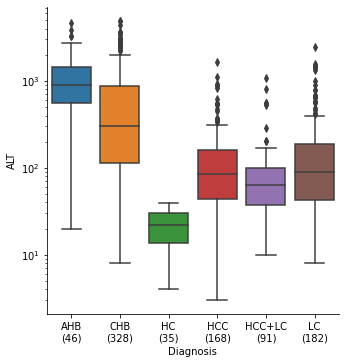

In [126]:
g=sns.catplot(data=dfALT, x="Diagnosis", y="ALT", kind="box")
g.set(yscale="log")
g.set_axis_labels("Diagnosis", "ALT")
#cnts = dict(dfALT['Diagnosis'].value_counts())
cnts={'AHB': 46,'CHB': 328, 'HC': 35, 'HCC': 168, 'HCC+LC': 91,'LC': 182}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('ALT.png',bbox_inches='tight')

In [127]:
Medians=dfALT.groupby(['Diagnosis'])['ALT'].median()
Medians

Diagnosis
AHB       897.5
CHB       300.0
HC         22.0
HCC        84.1
HCC+LC     63.0
LC         88.5
Name: ALT, dtype: float64

In [128]:
dfAFP = data.groupby(['Diagnosis','AFP']).size().reset_index()
dfAFP['AFP'].value_counts()

AFP
3.7       4
4.5       4
6.7       4
300       4
5.7       3
         ..
2.19      1
2.09      1
198       1
195.83    1
9.8       1
Name: count, Length: 652, dtype: int64

In [129]:
dfAFP.head()

,Diagnosis,AFP,0
0,CHB,1,1
1,CHB,1.08,1
2,CHB,1.12,1
3,CHB,1.22,1
4,CHB,1.24,1


In [130]:
dfAFP=dfAFP.dropna()

In [131]:
dfAFP.drop(dfAFP[dfAFP['AFP'] == 'm'].index, inplace = True)

In [132]:
dfAFP.drop(dfAFP[dfAFP['AFP'] == " "].index, inplace = True)

In [133]:
dfAFP=dfAFP.mask(dfAFP['AFP'] == '')

In [134]:
import numpy as np

In [135]:
np.where(pd.isnull(dfAFP['AFP']))

(array([], dtype=int64),)

In [136]:
dfAFP = dfAFP.replace('',np.nan,regex = True)

In [137]:
dfAFP.head()

,Diagnosis,AFP,0
0,CHB,1,1
1,CHB,1.08,1
2,CHB,1.12,1
3,CHB,1.22,1
4,CHB,1.24,1


In [136]:
#dfAFP.to_excel("AFP.xlsx", index=False)

In [138]:
dfAFP.dtypes

Diagnosis    object
AFP          object
0             int64
dtype: object

In [139]:
AFP=pd.read_excel("AFP.xlsx")

In [140]:
AFP.head()

,Diagnosis,AFP,0
0,CHB,1.00,1
1,CHB,1.08,1
2,CHB,1.12,1
3,CHB,1.22,1
4,CHB,1.24,1


In [140]:
#dfAFP['dfAFP']=pd.to_numeric(dfAFP['AFP'])

In [141]:
#dfAFP['dfAFP']=dfAFP['AFP'].astype(float)

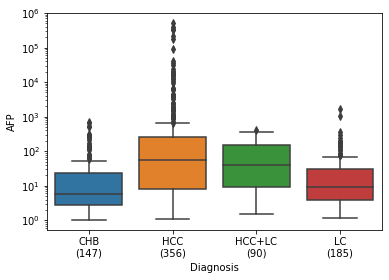

In [141]:
g=sns.boxplot(data=AFP, x="Diagnosis", y="AFP")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "AFP")
#cnts = dict(AFP['Diagnosis'].value_counts())
cnts={ 'CHB': 147,'HCC': 356, 'HCC+LC': 90,'LC': 185}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('AFP', bbox_inches='tight')

In [143]:
Medians=AFP.groupby(['Diagnosis'])['AFP'].median()

In [144]:
Medians

Diagnosis
CHB        5.70
HCC       54.85
HCC+LC    40.50
LC         9.17
Name: AFP, dtype: float64

In [145]:
data.head()

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101.0,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104.0,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268.0,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219.0,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219.0,10.5,10.5,1.8,1.8,36.1,94.0


In [146]:
data.isnull().sum()

Genes                  0
Diagnosis             27
Diag                  48
Patient ID             1
Age                   88
Gender               240
HBeAg               2284
AntiHBe             2289
HBV-Viral-load      1272
HBV-genotype        1889
AFP                 1118
AST                  186
ALT                  186
WBC                 1049
RBC                 1053
Platelets           1057
Total-Bilirubin      350
TotalBili            350
Direct-Bilirubin    1179
DirectBili          1179
Albumin             1360
Prothrombin          634
dtype: int64

In [147]:
dfWBC = data.groupby(['Diagnosis','WBC']).size().reset_index()
dfWBC['WBC'].value_counts()

WBC
7.40     5
7.70     5
6.60     5
4.80     5
7.20     5
        ..
7.69     1
7.65     1
7.63     1
7.56     1
28.65    1
Name: count, Length: 565, dtype: int64

In [148]:
dfWBC=dfWBC.dropna()

In [149]:
dfWBC.drop(dfWBC[dfWBC['WBC'] == 'm'].index, inplace = True)

In [150]:
dfWBC.drop(dfWBC[dfWBC['WBC'] == ''].index, inplace = True)

In [149]:
#dfWBC.to_excel("WBC.xlsx", index=False)

In [151]:
WBC=pd.read_excel("WBC.xlsx")

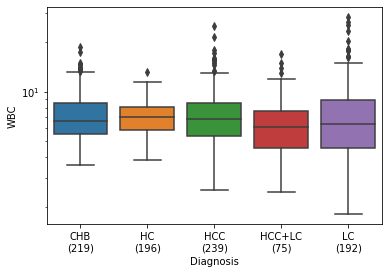

In [152]:
g=sns.boxplot(data=WBC, x="Diagnosis", y="WBC")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "WBC")
#cnts = dict(WBC['Diagnosis'].value_counts())
cnts={ 'CHB': 219,'HC': 196,'HCC': 239, 'HCC+LC': 75, 'LC': 192}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('WBC.png',bbox_inches='tight')

In [153]:
Medians=WBC.groupby(['Diagnosis'])['WBC'].median()

In [154]:
Medians

Diagnosis
CHB       6.650
HC        7.025
HCC       6.840
HCC+LC    6.100
LC        6.380
Name: WBC, dtype: float64

(array([540., 330.,  39.,   7.,   5.]),
 array([ 1.8 ,  7.17, 12.54, 17.91, 23.28, 28.65]),
 <BarContainer object of 5 artists>)

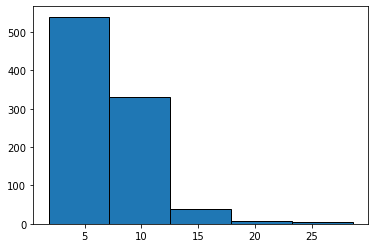

In [212]:
plt.hist(WBC['WBC'],edgecolor='black',bins=5)

In [155]:
dfRBC = data.groupby(['Diagnosis','RBC']).size().reset_index()
dfRBC['RBC'].value_counts()

RBC
4.40    5
5.00    5
5.10    5
4.10    5
4.30    5
       ..
3.37    1
3.19    1
3.17    1
2.97    1
6.94    1
Name: count, Length: 312, dtype: int64

In [156]:
dfRBC=dfRBC.dropna()

In [157]:
dfRBC.drop(dfRBC[dfRBC['RBC'] == 'm'].index, inplace = True)

In [158]:
dfRBC.drop(dfRBC[dfRBC['RBC'] == ''].index, inplace = True)

In [156]:
#dfRBC.to_excel("RBC.xlsx", index=False)

In [159]:
RBC=pd.read_excel("RBC.xlsx")

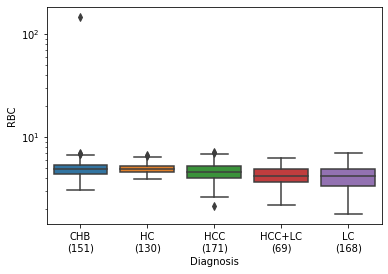

In [160]:
g=sns.boxplot(data=RBC, x="Diagnosis", y="RBC")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "ALT")
#cnts = dict(RBC['Diagnosis'].value_counts())
cnts={'CHB': 151,'HC': 130,'HCC': 171,  'HCC+LC': 69,'LC': 168}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('RBC.png',bbox_inches='tight')

In [161]:
Medians=RBC.groupby(['Diagnosis'])['RBC'].median()

In [162]:
Medians

Diagnosis
CHB       4.850
HC        4.865
HCC       4.590
HCC+LC    4.170
LC        4.195
Name: RBC, dtype: float64

(array([688.,   0.,   0.,   0.,   1.]),
 array([  1.76 ,  31.008,  60.256,  89.504, 118.752, 148.   ]),
 <BarContainer object of 5 artists>)

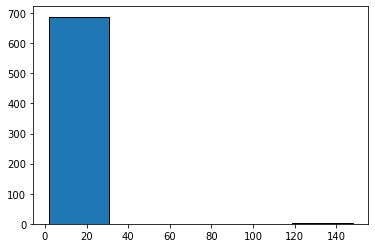

In [211]:
plt.hist(RBC['RBC'],edgecolor='black',bins=5)

In [163]:
dfPlt = data.groupby(['Diagnosis','Platelets']).size().reset_index()
dfPlt['Platelets'].value_counts()

Platelets
196.0    5
151.0    5
167.0    5
185.0    5
135.0    5
        ..
380.0    1
370.0    1
368.0    1
363.0    1
464.0    1
Name: count, Length: 366, dtype: int64

In [164]:
dfPlt=dfPlt.dropna()
dfPlt.drop(dfPlt[dfPlt['Platelets'] == 'm'].index, inplace = True)
dfPlt.drop(dfPlt[dfPlt['Platelets'] == ''].index, inplace = True)

In [161]:
#dfPlt.to_excel("Plt.xlsx", index=False)

In [165]:
Plt=pd.read_excel("Plt.xlsx")

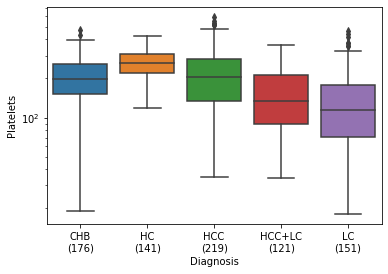

In [166]:
g=sns.boxplot(data=Plt, x="Diagnosis", y="Platelets")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "Platelet")
#cnts = dict(Plt['Diagnosis'].value_counts())
cnts={'CHB': 176,'HC': 141,'HCC': 219, 'HCC+LC': 121, 'LC': 151}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('Platelets.png',bbox_inches='tight')

In [167]:
Medians=Plt.groupby(['Diagnosis'])['Platelets'].median()

In [168]:
Medians

Diagnosis
CHB       199.5
HC        263.0
HCC       205.0
HCC+LC    134.0
LC        115.0
Name: Platelets, dtype: float64

In [169]:
dfTBb = data.groupby(['Diagnosis','Total-Bilirubin']).size().reset_index()
dfTBb['Total-Bilirubin'].value_counts()

Total-Bilirubin
11.0     5
15.0     5
24.0     5
26.0     5
16.0     5
        ..
294.0    1
289.0    1
285.7    1
284.7    1
752.0    1
Name: count, Length: 641, dtype: int64

In [170]:
dfTBb=dfTBb.dropna()
dfTBb.drop(dfTBb[dfTBb['Total-Bilirubin'] == 'm'].index, inplace = True)
dfTBb.drop(dfTBb[dfTBb['Total-Bilirubin'] == ''].index, inplace = True)

In [166]:
#dfTBb.to_excel("TBb.xlsx", index=False)

In [171]:
TBb=pd.read_excel("TBb.xlsx")

In [172]:
TBb.head()

,Diagnosis,Total-Bilirubin,0
0,AHB,100.00,1
1,AHB,101.00,1
2,AHB,102.88,1
3,AHB,102.90,1
4,AHB,11.00,2


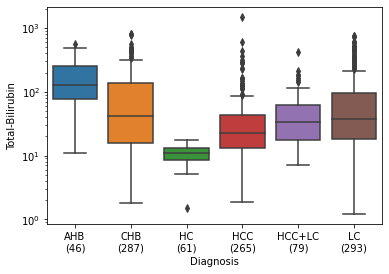

In [173]:
g=sns.boxplot(data=TBb, x="Diagnosis", y="Total-Bilirubin")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "ALT")
#cnts = dict(TBb['Diagnosis'].value_counts())
cnts={'AHB': 46,'CHB': 287,'HC': 61,'HCC': 265, 'HCC+LC': 79,'LC': 293}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('Total-Bilirubin.png',bbox_inches='tight')

In [174]:
Medians=TBb.groupby(['Diagnosis'])['Total-Bilirubin'].median()

In [175]:
Medians

Diagnosis
AHB       128.525
CHB        41.000
HC         11.100
HCC        22.900
HCC+LC     34.000
LC         37.000
Name: Total-Bilirubin, dtype: float64

In [176]:
dfDBb = data.groupby(['Diagnosis','Direct-Bilirubin']).size().reset_index()
dfDBb['Diagnosis'].value_counts()

Diagnosis
LC     214
CHB    201
HCC    194
AHB     49
HC       4
Name: count, dtype: int64

In [177]:
dfDBb.head()

,Diagnosis,Direct-Bilirubin,0
0,AHB,5.00,2
1,AHB,5.75,1
2,AHB,11.00,1
3,AHB,14.26,1
4,AHB,14.30,1


In [178]:
dfDBb=dfDBb.dropna()
dfDBb.drop(dfDBb[dfDBb['Direct-Bilirubin'] == 'm'].index, inplace = True)
dfDBb.drop(dfDBb[dfDBb['Direct-Bilirubin'] == ''].index, inplace = True)

In [173]:
#dfDBb.to_excel("DBb.xlsx", index=False)

In [179]:
DBb=pd.read_excel("DBb.xlsx")

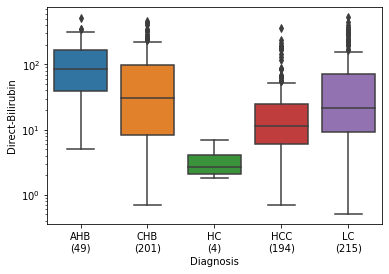

In [180]:
g=sns.boxplot(data=DBb, x="Diagnosis", y="Direct-Bilirubin")
g.set(yscale="log")
#g.set_axis_labels("Diagnosis", "Direct-Bilirubin")
#cnts = dict(DBb['Diagnosis'].value_counts())
cnts={'AHB': 49,'CHB': 201,'HC': 4,'HCC': 194,'LC': 215}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('Direct-Bilirubin.png',bbox_inches='tight')

In [185]:
Medians=DBb.groupby(['Diagnosis'])['Direct-Bilirubin'].median()

In [186]:
Medians

Diagnosis
AHB    86.30
CHB    30.20
HC      2.65
HCC    11.35
LC     21.50
Name: Direct-Bilirubin, dtype: float64

In [187]:
dfAlb = data.groupby(['Diagnosis','Albumin']).size().reset_index()
dfAlb['Diagnosis'].value_counts()

Diagnosis
HCC       115
CHB       108
LC         95
HC         35
HCC+LC     33
Name: count, dtype: int64

In [188]:
dfAlb=dfAlb.dropna()
dfAlb.drop(dfAlb[dfAlb['Albumin'] == 'm'].index, inplace = True)
dfAlb.drop(dfAlb[dfAlb['Albumin'] == ''].index, inplace = True)

In [177]:
#dfAlb.to_excel("Alb.xlsx", index=False)

In [189]:
Alb=pd.read_excel("Alb.xlsx")

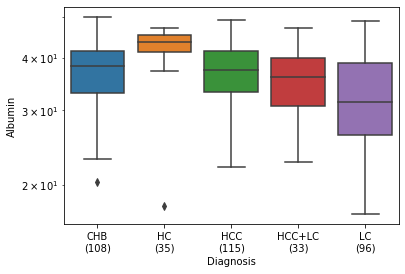

In [190]:
g=sns.boxplot(data=Alb, x="Diagnosis", y="Albumin")
g.set(yscale="log")
#cnts = dict(Alb['Diagnosis'].value_counts())
cnts={'CHB': 108,'HC': 35,'HCC': 115,'HCC+LC': 33, 'LC': 96}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('Albumin.png',bbox_inches='tight')

In [191]:
Medians=Alb.groupby(['Diagnosis'])['Albumin'].median()

In [192]:
Medians

Diagnosis
CHB       38.1
HC        43.6
HCC       37.4
HCC+LC    36.0
LC        31.4
Name: Albumin, dtype: float64

In [193]:
dfPrb = data.groupby(['Diagnosis','Prothrombin']).size().reset_index()
dfPrb['Prothrombin'].value_counts()

Prothrombin
81.0     5
76.0     5
50.0     5
90.0     5
86.0     5
        ..
111.0    1
55.7     1
92.6     1
50.4     1
64.2     1
Name: count, Length: 159, dtype: int64

In [194]:
dfPrb=dfPrb.dropna()
dfPrb.drop(dfPrb[dfPrb['Prothrombin'] == 'm'].index, inplace = True)
dfPrb.drop(dfPrb[dfPrb['Prothrombin'] == ''].index, inplace = True)

In [182]:
#dfPrb.to_excel("Prb.xlsx", index=False)

In [183]:
#Prb=pd.read_excel("Prb.xlsx")

In [195]:
Prb=pd.read_excel('Prb1.xlsx')

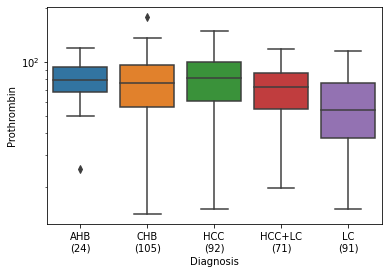

In [196]:
g=sns.boxplot(data=Prb, x="Diagnosis", y="Prothrombin")
g.set(yscale="log")
#cnts = dict(Prb['Diagnosis'].value_counts())
cnts={'AHB': 24, 'CHB': 105, 'HCC': 92,'HCC+LC': 71,'LC': 91}
key = list(cnts.keys())
vals = list(cnts.values())
g.set_xticklabels([(key[i]+'\n('+str(vals[i])+')') for i in range(len(key))])
plt.savefig('Prothrombin.png',bbox_inches='tight')

In [197]:
Medians=Prb.groupby(['Diagnosis'])['Prothrombin'].median()

In [198]:
Medians

Diagnosis
AHB       79.5
CHB       76.5
HCC       81.8
HCC+LC    72.9
LC        54.0
Name: Prothrombin, dtype: float64

In [186]:
#pip install statannot

In [187]:
from statannot import add_stat_annotation

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CHB v.s. LC: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.100e-05 U_stat=6.612e+03
AHB v.s. LC: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.895e-04 U_stat=1.634e+03
AHB v.s. HCC: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.000e+00 U_stat=1.086e+03


[None]

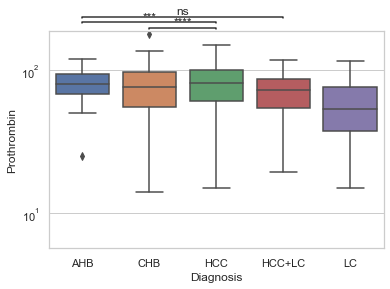

In [188]:
sns.set(style="whitegrid")
order = ['AHB','CHB','LC','HCC','HCC+LC']

g=sns.boxplot(data=Prb, x="Diagnosis", y="Prothrombin")
add_stat_annotation(g, data=Prb, x="Diagnosis", y="Prothrombin", order=order,
                    box_pairs=[("AHB", "LC"), ("CHB", "LC"), ("AHB", "HCC")],
                    test='Mann-Whitney', text_format='star', loc='outside', verbose=2)
g.set(yscale="log")

In [189]:
#Prb.boxplot('Prothrombin',by='Diagnosis')

# Correlation analysis

In [190]:
dfALT.head()

,Diagnosis,ALT,0
0,AHB,20.0,2
1,AHB,115.5,2
2,AHB,145.0,1
3,AHB,202.0,1
4,AHB,286.0,1


In [191]:
dfALT.sort_values('Diagnosis')

,Diagnosis,ALT,0
0,AHB,20.0,2
25,AHB,1015.0,1
26,AHB,1100.0,2
27,AHB,1118.0,1
28,AHB,1133.0,1
...,...,...,...
730,LC,56.0,4
731,LC,57.0,8
732,LC,58.0,2
734,LC,60.0,8


In [192]:
#dfALT.to_excel('ALT.xlsx',index=False)

In [193]:
ALT=pd.read_excel('ALT.xlsx')

In [194]:
ALT['Diagnosis'].value_counts()

Diagnosis
CHB       328
LC        184
HCC       168
HCC+LC     91
AHB        46
HC         35
Name: count, dtype: int64

In [195]:
ALT.shape[0]

852

In [196]:
range(len(ALT))

range(0, 852)

In [197]:
Count = []
ahb = 0
chb = 0
hcc = 0
lc = 0
hcclc = 0
hc = 0

In [198]:
for i in range(ALT.shape[0]):
    if (ALT.loc[i,'Diagnosis'] == 'AHB'):   
        ahb+=1
        Count.append(ahb)
    elif (ALT.loc[i,'Diagnosis'] == 'CHB'):
        chb+=1
        Count.append(chb)
    elif (ALT.loc[i,'Diagnosis'] == 'HCC'):
        hcc+=1
        Count.append(hcc)
    elif (ALT.loc[i,'Diagnosis'] == 'LC'):
        lc+=1
        Count.append(lc)
    elif (ALT.loc[i,'Diagnosis'] == 'HCC+LC'):
        hcclc+=1
        Count.append(hcclc)
    elif (ALT.loc[i,'Diagnosis'] == 'HC'):
        hc+=1
        Count.append(hc)
    else:Count.append('NA')

In [199]:
#print(Count)

In [200]:
ALT['Count']=Count

In [201]:
ALT.head()

,Diagnosis,ALT,0,Count
0,AHB,20.0,2,1
1,AHB,115.5,2,2
2,AHB,145.0,1,3
3,AHB,202.0,1,4
4,AHB,286.0,1,5


In [202]:
ALT=ALT.drop([0],axis=1)

In [203]:
ALT.head()

,Diagnosis,ALT,Count
0,AHB,20.0,1
1,AHB,115.5,2
2,AHB,145.0,3
3,AHB,202.0,4
4,AHB,286.0,5


In [204]:
#observation_size = ALT.shape[0]

In [205]:
#observation_size

In [206]:
df = ALT.pivot(columns='Diagnosis', index='Count')
display(df)

ALT                                
Diagnosis    AHB     CHB   HC   HCC HCC+LC    LC
Count                                           
1           20.0     8.0  4.0   3.0   10.0   8.0
2          115.5     9.0  6.0   8.0   11.0   9.0
3          145.0    10.0  7.0  10.0   12.0  10.0
4          202.0    11.0  8.0  11.0   13.0  11.0
5          286.0    11.8  9.0  11.2   14.0  12.0
...          ...     ...  ...   ...    ...   ...
324          NaN  3642.0  NaN   NaN    NaN   NaN
325          NaN  3668.0  NaN   NaN    NaN   NaN
326          NaN  4427.0  NaN   NaN    NaN   NaN
327          NaN  4908.0  NaN   NaN    NaN   NaN
328          NaN  4926.0  NaN   NaN    NaN   NaN

[328 rows x 6 columns]

In [207]:
#df.to_excel('ALT-Pivot.xlsx')

In [208]:
#df=pd.read_excel('ALT-Pivot.xlsx')

In [209]:
df.drop(df.loc[36:328].index, inplace=True)

In [210]:
n = df.shape[0]   # number of items in each group
k = df.shape[1]   # number of groups

In [211]:
observation_size = df.shape[0]

In [212]:
df.head()

ALT                              
Diagnosis    AHB   CHB   HC   HCC HCC+LC    LC
Count                                         
1           20.0   8.0  4.0   3.0   10.0   8.0
2          115.5   9.0  6.0   8.0   11.0   9.0
3          145.0  10.0  7.0  10.0   12.0  10.0
4          202.0  11.0  8.0  11.0   13.0  11.0
5          286.0  11.8  9.0  11.2   14.0  12.0

##### Defining the Hypotheses
We now define the null hypothesis and alternate hypothesis, just like the chi-square test. They are:

H₀ (Null hypothesis) — that there is no difference among group means.
H₁ (Alternate hypothesis) — that at least one group differs significantly from the overall mean of the dependent variable.

# Step 1 — Calculating the means for all groups

In [213]:
df.loc['Group Means'] = df.mean()
df

ALT                                                   
Diagnosis        AHB    CHB         HC        HCC     HCC+LC         LC
Count                                                                  
1              20.00   8.00   4.000000   3.000000  10.000000   8.000000
2             115.50   9.00   6.000000   8.000000  11.000000   9.000000
3             145.00  10.00   7.000000  10.000000  12.000000  10.000000
4             202.00  11.00   8.000000  11.000000  13.000000  11.000000
5             286.00  11.80   9.000000  11.200000  14.000000  12.000000
6             309.00  13.00  10.000000  12.000000  16.000000  13.000000
7             351.00  14.00  11.000000  13.000000  19.000000  14.000000
8             493.00  15.00  12.000000  14.000000  20.000000  15.000000
9             500.00  17.00  13.000000  15.000000  21.000000  15.500000
10            502.00  18.00  14.000000  15.600000  22.000000  16.000000
11            548.00  19.00  15.000000  16.000000  23.000000  17.000000
12            562.00  20.00  16.000000  17.000000  24.000000  18.000000
13            569.00  21.00  17.000000  18.000000  25.000000  19.000000
14            616.00  22.00  18.000000  19.000000  26.000000  20.000000
15            645.00  23.00  19.000000  20.000000  27.000000  21.000000
16            672.00  24.00  20.000000  21.000000  28.000000  22.000000
17            795.00  25.00  21.000000  22.000000  30.000000  23.000000
18            799.00  26.00  22.000000  23.000000  31.000000  24.000000
19            834.00  27.00  23.000000  24.000000  32.000000  24.900000
20            835.00  28.00  24.000000  25.000000  34.000000  25.000000
21            864.40  30.00  25.000000  26.000000  35.000000  26.000000
22            869.00  31.00  26.000000  27.000000  36.000000  27.000000
23            872.00  32.00  27.000000  28.000000  37.000000  28.000000
24            923.00  33.00  28.000000  29.000000  38.000000  28.600000
25            993.00  34.00  29.000000  30.000000  39.000000  29.000000
26           1015.00  35.00  30.000000  31.000000  40.000000  30.000000
27           1100.00  36.00  31.000000  32.000000  41.000000  31.000000
28           1118.00  37.00  32.000000  33.000000  42.000000  32.000000
29           1133.00  38.00  33.000000  34.000000  44.000000  33.000000
30           1194.00  39.00  34.000000  35.000000  45.000000  33.100000
31           1195.00  40.00  35.000000  35.100000  46.000000  34.000000
32           1271.00  41.00  36.000000  36.000000  47.000000  35.000000
33           1361.00  41.50  37.000000  36.500000  48.000000  36.000000
34           1373.00  42.00  38.000000  37.000000  49.000000  37.000000
35           1490.00  45.00  39.000000  38.000000  50.000000  38.000000
Group Means   759.14  26.18  21.971429  23.011429  30.714286  23.288571

In [214]:
df.iloc[-1]

     Diagnosis
ALT  AHB          759.140000
     CHB           26.180000
     HC            21.971429
     HCC           23.011429
     HCC+LC        30.714286
     LC            23.288571
Name: Group Means, dtype: float64

# Calculate the overall mean

In [215]:
overall_mean = df.iloc[-1].mean()
overall_mean 

147.3842857142857

# Step 2 — Calculate the Sum of Squares

###### Now that we have calculated the overall mean, we can proceed to calculate the following:

Sum of squares of all observations — SS_total
Sum of squares within — SS_within
Sum of squares between — SS_between
Sum of squares of all observations — SS_total
The sum of squares of all observations is calculated by deducting each observation from the overall mean, and then summing all the squares of the differences:



In [216]:
SS_total = (((df.iloc[:-1] - overall_mean)**2).sum()).sum()
SS_total

20840842.178142864

In [217]:
SS_within = (((df.iloc[:-1] - df.iloc[-1])**2).sum()).sum()
SS_within

5120796.565142859

In [218]:
SS_between = (n * (df.iloc[-1] - overall_mean)**2).sum()
SS_between 

15720045.612999998

Creating the ANOVA Table

We can compute the various degrees of freedoms as follows:

In [219]:
df_total = observation_size - 1        
df_within = observation_size - k       
df_between = k - 1 

From the above, compute the various mean squared values:

In [220]:
mean_sq_between = SS_between / (k - 1)    
mean_sq_within = SS_within / (observation_size - k)

Finally, we can calculate the F-value, which is the ratio of two variances:

In [221]:
F = mean_sq_between / mean_sq_within 

In [222]:
F

17.80509406994112

Once the F-value is obtained, we now have to refer to the f-distribution table (see http://www.socr.ucla.edu/Applets.dir/F_Table.html for one example) to obtain the f-critical value. The f-distribution table is organized based on the α value (usually 0.05). So we need to first locate the table based on α=0.05:

Next, observe that the columns of the f-distribution table are based on df1 while the rows are based on df2. We can get  df1 and df2 from the previous variables that we have created:

In [223]:
df1 = df_between   
df2 = df_within

In [224]:
df1

5

In [225]:
df2

29

Using the Stats module to calculate f-score

In [226]:
import scipy.stats as stats

In [227]:
fvalue, pvalue = stats.f_oneway(
    df.iloc[:-1,0],
    df.iloc[:-1,1],
    df.iloc[:-1,2],
    df.iloc[:-1,3],
    df.iloc[:-1,4],
    df.iloc[:-1,5])
    
print(fvalue, pvalue)

125.24962725062056 3.456467128167579e-60


In [228]:
fvalue, pvalue = stats.f_oneway(*df.iloc[:-1,0:5].T.values) #Observe that the f_oneway() function takes in a variable number of arguments (no. of columns or categorical items)
print(fvalue, pvalue)

125.16560947191857 1.3949882388166569e-49


Using the statsmodels module to calculate f-score

In [229]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [230]:
df = pd.read_excel('ALT.xlsx')
model = ols('ALT ~ Diagnosis', data=df).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
Diagnosis,8.425784e+07,5.0,43.54929,5.194675e-40
Residual,3.273630e+08,846.0,NaN,NaN


To find the F critical value

In [231]:
#Fcritical=stats.f.ppf(significance level, df1, df2)

In [232]:
stats.f.ppf(q=1-.05, dfn=5, dfd=29)

2.5453864879485453

# Kruskal-Wallis 

In [199]:
from scipy import stats

In [221]:
WBC['Diagnosis'].value_counts()

Diagnosis
HCC       239
CHB       219
HC        196
LC        192
HCC+LC     75
Name: count, dtype: int64

In [222]:
y='WBC'

In [223]:
#Define a function for the Kruskal-Wallis test
def extrDiag(x,y):
    HCC=x.loc[x['Diagnosis']=='HCC',y]
    CHB=x.loc[x['Diagnosis']=='CHB',y]
    LC=x.loc[x['Diagnosis']=='LC',y]
    HCCLC=x.loc[x['Diagnosis']=='HCC+LC',y]
    HC=x.loc[x['Diagnosis']=='HC',y]
    return (stats.kruskal(HCC,CHB,LC,HCCLC,HC))

In [224]:
extrDiag(WBC,y)

KruskalResult(statistic=13.257178660259727, pvalue=0.01008519888825034)

In [226]:
HCC=WBC.loc[WBC['Diagnosis']=='HCC',y]

In [229]:
HCC.mean()

7.420083682008369

# Pearson correlation

In [250]:
import scipy.stats
import numpy as np

In [239]:
data.head()

,Genes,Diagnosis,Diag,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,...,ALT,WBC,RBC,Platelets,Total-Bilirubin,TotalBili,Direct-Bilirubin,DirectBili,Albumin,Prothrombin
0,PD1,HCC,4.0,A3-1,51.0,Male,NaN,NaN,NaN,NaN,...,343.0,6.93,6.13,101.0,7.4,7.4,2.4,2.4,42.6,105.0
1,PD1,HCC,4.0,A3-2,36.0,Male,NaN,NaN,NaN,NaN,...,37.0,3.95,4.63,104.0,15.7,15.7,7.0,7.0,42.3,85.0
2,PD1,HCC,4.0,A3-3,48.0,Female,NaN,NaN,NaN,NaN,...,30.0,5.14,3.81,268.0,8.7,8.7,0.7,0.7,NaN,87.0
3,PD1,HCC,4.0,A3-4,61.0,Male,NaN,NaN,NaN,NaN,...,45.0,7.74,5.32,219.0,25.3,25.3,5.7,5.7,NaN,105.0
4,PD1,HCC,4.0,A3-6,71.0,Male,NaN,NaN,NaN,NaN,...,54.0,4.73,4.73,219.0,10.5,10.5,1.8,1.8,36.1,94.0


In [240]:
dfAFP['Diagnosis'].value_counts()

Diagnosis
HCC       354
LC        184
CHB       147
HCC+LC     91
Name: count, dtype: int64

In [246]:
dfAFP.loc[dfAFP['Diagnosis'] == 'HCC','Diag'] = '2'
dfAFP.loc[dfAFP['Diagnosis'] == 'HCC+LC','Diag'] = '1'
dfAFP.loc[dfAFP['Diagnosis'] == 'LC','Diag'] = '3'
dfAFP.loc[dfAFP['Diagnosis'] == 'CHB','Diag'] = '4'

In [242]:
#dfAFP.drop(['Diag'],axis=1,inplace=True)

In [243]:
#dfAFP.drop(index=dfAFP.index[-1],axis=0,inplace=True)

In [267]:
dfAFP['AFP'].replace('',np.nan,inplace=True)

In [268]:
dfAFP.dropna(subset=['AFP'],inplace=True)

In [ ]:
#dfAFP.to_excel('dfAFP.xlsx',index=False)

In [273]:
dfAFP=pd.read_excel('dfAFP.xlsx')

In [275]:
dfAFP['AFP'] = dfAFP['AFP'].astype(int)

In [276]:
dfAFP['Diag'] = dfAFP['Diag'].astype(int)

In [277]:
x=dfAFP['Diag']
y=dfAFP['AFP']

In [279]:
r=np.corrcoef(x,y)

In [281]:
r

array([[ 1.        , -0.05573761],
       [-0.05573761,  1.        ]])

In [280]:
scipy.stats.pearsonr(x, y)

(-0.05573760991737845, 0.12105268963352282)

In [306]:
AST=pd.read_excel('AST.xlsx')

TypeError: read_excel() got an unexpected keyword argument 'index'

In [292]:
AST['Diagnosis'].value_counts()

Diagnosis
CHB       312
LC        210
HCC       200
HCC+LC     99
AHB        45
HC         29
Name: count, dtype: int64

In [296]:
AST.loc[AST['Diagnosis'] == 'HCC+LC','Diag'] = '1'
AST.loc[AST['Diagnosis'] == 'HCC','Diag'] = '2'
AST.loc[AST['Diagnosis'] == 'LC','Diag'] = '3'
AST.loc[AST['Diagnosis'] == 'CHB','Diag'] = '4'
AST.loc[AST['Diagnosis'] == 'AHB','Diag'] = '5'
AST.loc[AST['Diagnosis'] == 'HC','Diag'] = '6'

In [298]:
AST.head()

,Unnamed: 0,Diagnosis,AST,0,Diag
0,0,AHB,27.0,2,5
1,1,AHB,127.0,1,5
2,2,AHB,182.0,1,5
3,3,AHB,295.0,1,5
4,4,AHB,295.3,2,5


In [301]:
AST['Diag']=AST['Diag'].astype(int)

In [302]:
x=AST['Diag']
y=AST['AST']

In [303]:
r=np.corrcoef(x,y)

In [304]:
r

array([[1.        , 0.26384667],
       [0.26384667, 1.        ]])

In [305]:
scipy.stats.pearsonr(x,y)

(0.2638466656221072, 1.0154622510439493e-15)

Create sub-groups

In [39]:
HC=data.loc[data['Diagnosis']=='HC',['Genes','Diagnosis','Age','Gender','HBeAg','AntiHBe','HBV-Viral-load','HBV-genotype','AFP','ALT','AST','WBC','RBC','Platelets','Total-Bilirubin','Albumin','Prothrombin']]

In [40]:
HC.head()

,Genes,Diagnosis,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,AFP,ALT,AST,WBC,RBC,Platelets,Total-Bilirubin,Albumin,Prothrombin
551,PD1,HC,44.0,Male,NaN,NaN,NaN,NaN,NaN,10.0,22.0,5.71,4.57,211,10,45.8,NaN
552,PD1,HC,46.0,Female,NaN,NaN,NaN,NaN,NaN,9.0,14.0,4.76,4.53,250,9.6,40.6,NaN
553,PD1,HC,39.0,Female,NaN,NaN,NaN,NaN,NaN,13.0,27.0,7.29,3.99,328,11.4,41.1,NaN
554,PD1,HC,42.0,Male,NaN,NaN,NaN,NaN,NaN,30.0,26.0,8.61,5.25,324,8.4,43.5,NaN
555,PD1,HC,43.0,Male,NaN,NaN,NaN,NaN,NaN,26.0,21.0,7.06,5.73,265,12.5,45.4,NaN


In [41]:
HC.isnull().sum()

Genes                0
Diagnosis            0
Age                418
Gender             418
HBeAg              977
AntiHBe            977
HBV-Viral-load     977
HBV-genotype       977
AFP                977
ALT                737
AST                737
WBC                737
RBC                737
Platelets          737
Total-Bilirubin    880
Albumin            930
Prothrombin        976
dtype: int64

In [42]:
(data.isnull().sum())- (HC.isnull().sum())

AFP                  883.0
ALT                  192.0
AST                  192.0
Age                   88.0
Albumin             1175.0
AntiHBe             2057.0
Diagnosis             27.0
Direct-Bilirubin       NaN
Gender               240.0
Genes                  0.0
HBV-Viral-load      1040.0
HBV-genotype        1666.0
HBeAg               2052.0
Patient ID             NaN
Platelets           1063.0
Prothrombin          399.0
RBC                 1060.0
Total-Bilirubin      214.0
WBC                 1056.0
dtype: float64

In [43]:
data.describe()

,Age,AST,ALT
count,2690.000000,2267.000000,2267.000000
mean,48.608178,196.491681,212.253948
std,13.962776,413.799858,496.059949
min,15.000000,3.000000,3.000000
25%,39.000000,37.000000,30.500000
50%,49.000000,69.000000,55.000000
75%,59.000000,161.000000,132.000000
max,90.000000,7700.000000,4926.000000


In [44]:
df = pd.DataFrame(data)

In [45]:
df.head()

,Genes,Diagnosis,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin
0,PD1,HCC,A3-1,51.0,Male,NaN,NaN,NaN,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105
1,PD1,HCC,A3-2,36.0,Male,NaN,NaN,NaN,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85
2,PD1,HCC,A3-3,48.0,Female,NaN,NaN,NaN,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87
3,PD1,HCC,A3-4,61.0,Male,NaN,NaN,NaN,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105
4,PD1,HCC,A3-5,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
biochemical_data=df[['Diagnosis','Patient ID','Age','HBV-Viral-load','HBV-genotype','Gender','AFP','ALT','AST','WBC','RBC','Prothrombin','Platelets','Albumin','Total-Bilirubin','Direct-Bilirubin']]

In [47]:
biochemical_data.head()

,Diagnosis,Patient ID,Age,HBV-Viral-load,HBV-genotype,Gender,AFP,ALT,AST,WBC,RBC,Prothrombin,Platelets,Albumin,Total-Bilirubin,Direct-Bilirubin
0,HCC,A3-1,51.0,NaN,NaN,Male,17.26,343.0,127.0,6.93,6.13,105,101,42.6,7.4,2.4
1,HCC,A3-2,36.0,NaN,NaN,Male,62.24,37.0,42.0,3.95,4.63,85,104,42.3,15.7,7
2,HCC,A3-3,48.0,NaN,NaN,Female,2479.34,30.0,37.0,5.14,3.81,87,268,NaN,8.7,0.7
3,HCC,A3-4,61.0,NaN,NaN,Male,1053.71,45.0,84.0,7.74,5.32,105,219,NaN,25.3,5.7
4,HCC,A3-5,50.0,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
df['AST'].isnull().sum()

929

In [49]:
filtered_AST = df['AST'].dropna()

In [50]:
filtered_AST.isnull().sum()

0

In [51]:
df['ALT'].isnull().sum()

929

In [52]:
filtered_ALT = df['ALT'].dropna()

In [53]:
filtered_ALT.isnull().sum()

0

In [54]:
HCC=data.loc[data['Diagnosis']=='HCC']

In [55]:
HCC.head()

,Genes,Diagnosis,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin
0,PD1,HCC,A3-1,51.0,Male,NaN,NaN,NaN,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105
1,PD1,HCC,A3-2,36.0,Male,NaN,NaN,NaN,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85
2,PD1,HCC,A3-3,48.0,Female,NaN,NaN,NaN,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87
3,PD1,HCC,A3-4,61.0,Male,NaN,NaN,NaN,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105
4,PD1,HCC,A3-5,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
HCC.isnull().sum()

Genes                 0
Diagnosis             0
Patient ID            0
Age                  21
Gender               78
HBeAg               693
AntiHBe             697
HBV-Viral-load      401
HBV-genotype        545
AFP                  69
AST                  14
ALT                  14
WBC                 320
RBC                 320
Platelets           320
Total-Bilirubin      16
Direct-Bilirubin    208
Albumin             350
Prothrombin          61
dtype: int64

In [57]:
LC=data.loc[data['Diagnosis']=='LC']

In [58]:
LC.isnull().sum()

Genes                 0
Diagnosis             0
Patient ID            0
Age                   0
Gender               49
HBeAg               539
AntiHBe             539
HBV-Viral-load      280
HBV-genotype        427
AFP                 272
AST                   7
ALT                   7
WBC                 308
RBC                 308
Platelets           308
Total-Bilirubin      16
Direct-Bilirubin    188
Albumin             343
Prothrombin          82
dtype: int64

In [59]:
CHB=data.loc[data['Diagnosis']=='CHB']

In [60]:
CHB.isnull().sum()

Genes                 0
Diagnosis             0
Patient ID            0
Age                  24
Gender               62
HBeAg               493
AntiHBe             494
HBV-Viral-load      210
HBV-genotype        486
AFP                 392
AST                  85
ALT                  85
WBC                 277
RBC                 281
Platelets           284
Total-Bilirubin      95
Direct-Bilirubin    293
Albumin             331
Prothrombin         169
dtype: int64

In [61]:
import pandas as pd
import numpy as np 
from scipy.stats import chi2, norm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [62]:
HC.head()

,Genes,Diagnosis,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,AFP,ALT,AST,WBC,RBC,Platelets,Total-Bilirubin,Albumin,Prothrombin
551,PD1,HC,44.0,Male,NaN,NaN,NaN,NaN,NaN,10.0,22.0,5.71,4.57,211,10,45.8,NaN
552,PD1,HC,46.0,Female,NaN,NaN,NaN,NaN,NaN,9.0,14.0,4.76,4.53,250,9.6,40.6,NaN
553,PD1,HC,39.0,Female,NaN,NaN,NaN,NaN,NaN,13.0,27.0,7.29,3.99,328,11.4,41.1,NaN
554,PD1,HC,42.0,Male,NaN,NaN,NaN,NaN,NaN,30.0,26.0,8.61,5.25,324,8.4,43.5,NaN
555,PD1,HC,43.0,Male,NaN,NaN,NaN,NaN,NaN,26.0,21.0,7.06,5.73,265,12.5,45.4,NaN


In [63]:
HC1=HC.drop(['Genes','Diagnosis','Gender','HBeAg','AntiHBe','AFP'],axis=1)

In [64]:
HC1=HC1.drop(['Prothrombin'],axis=1)

In [65]:
HC1.head()

,Age,HBV-Viral-load,HBV-genotype,ALT,AST,WBC,RBC,Platelets,Total-Bilirubin,Albumin
551,44.0,NaN,NaN,10.0,22.0,5.71,4.57,211,10,45.8
552,46.0,NaN,NaN,9.0,14.0,4.76,4.53,250,9.6,40.6
553,39.0,NaN,NaN,13.0,27.0,7.29,3.99,328,11.4,41.1
554,42.0,NaN,NaN,30.0,26.0,8.61,5.25,324,8.4,43.5
555,43.0,NaN,NaN,26.0,21.0,7.06,5.73,265,12.5,45.4


In [66]:
HC1.dropna()

,Age,HBV-Viral-load,HBV-genotype,ALT,AST,WBC,RBC,Platelets,Total-Bilirubin,Albumin


In [67]:
print(HC1.shape)

(977, 10)


In [68]:
HC1.head()

,Age,HBV-Viral-load,HBV-genotype,ALT,AST,WBC,RBC,Platelets,Total-Bilirubin,Albumin
551,44.0,NaN,NaN,10.0,22.0,5.71,4.57,211,10,45.8
552,46.0,NaN,NaN,9.0,14.0,4.76,4.53,250,9.6,40.6
553,39.0,NaN,NaN,13.0,27.0,7.29,3.99,328,11.4,41.1
554,42.0,NaN,NaN,30.0,26.0,8.61,5.25,324,8.4,43.5
555,43.0,NaN,NaN,26.0,21.0,7.06,5.73,265,12.5,45.4


In [239]:
#sns.pairplot(data=HC1,vars=['Age','ALT','AST','WBC','RBC','Platelets','Total Bilirubin','Albumin'])

In [69]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

In [70]:
data.head()

,Genes,Diagnosis,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV-Viral-load,HBV-genotype,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin
0,PD1,HCC,A3-1,51.0,Male,NaN,NaN,NaN,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105
1,PD1,HCC,A3-2,36.0,Male,NaN,NaN,NaN,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85
2,PD1,HCC,A3-3,48.0,Female,NaN,NaN,NaN,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87
3,PD1,HCC,A3-4,61.0,Male,NaN,NaN,NaN,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105
4,PD1,HCC,A3-5,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
df1=data.drop(['Patient ID','HBeAg','AntiHBe','HBV-genotype'],axis=1)

In [72]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df1.isnull().sum()

Genes                  0
Diagnosis             27
Age                  506
Gender               658
HBV-Viral-load      2017
AFP                 1860
AST                  929
ALT                  929
WBC                 1793
RBC                 1797
Platelets           1800
Total-Bilirubin     1094
Direct-Bilirubin    1923
Albumin             2105
Prothrombin         1375
dtype: int64

In [74]:
df1.shape

(3196, 15)

In [75]:
3660-2229
3660-1924

1431

1736

In [76]:
le.fit(df1['Genes'])

LabelEncoder()

In [77]:
df1['genes']=le.transform(df1['Genes'])

In [78]:
df1['genes']

0       3
1       3
2       3
3       3
4       3
       ..
3191    1
3192    1
3193    1
3194    1
3195    1
Name: genes, Length: 3196, dtype: int32

In [79]:
list(le.classes_)

['CISH_FCN2_MICA', 'IRF15', 'ISG15_SOCS3', 'PD1']

In [80]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105,3
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85,3
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87,3
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105,3
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [81]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105,3
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85,3
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87,3
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105,3
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [82]:
le.fit(df1['Diagnosis'])

LabelEncoder()

In [83]:
df1['diag']=le.transform(df1['Diagnosis'])

In [84]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes,diag
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105,3,4
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85,3,4
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87,3,4
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105,3,4
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4


In [85]:
list(le.classes_)

['AHB', 'ASY', 'CHB', 'HC', 'HCC', 'HCC+LC', 'LC', 'bowel cancer', nan]

In [86]:
le.fit(df1['Gender'])
df1['gender']=le.transform(df1['Gender'])

LabelEncoder()

In [87]:
df1['gender']=le.transform(df1['Gender'])

In [88]:
list(le.classes_)

['Female', 'Male', nan]

In [89]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes,diag,gender
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105,3,4,1
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85,3,4,1
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87,3,4,0
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105,3,4,1
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1


In [90]:
#df1=df1.drop(['Genes','Diagnosis','Gender'],axis=1)

In [91]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes,diag,gender
0,PD1,HCC,51.0,Male,NaN,17.26,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105,3,4,1
1,PD1,HCC,36.0,Male,NaN,62.24,42.0,37.0,3.95,4.63,104,15.7,7,42.3,85,3,4,1
2,PD1,HCC,48.0,Female,NaN,2479.34,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87,3,4,0
3,PD1,HCC,61.0,Male,NaN,1053.71,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105,3,4,1
4,PD1,HCC,50.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1


In [92]:
df1.to_excel("HBV_label_encoded.xlsx", sheet_name="Biochemical", index=False)

In [93]:
df1=df1.dropna()

In [94]:
df1.head()

,Genes,Diagnosis,Age,Gender,HBV-Viral-load,AFP,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,Direct-Bilirubin,Albumin,Prothrombin,genes,diag,gender
47,PD1,HCC,68.0,Male,83600000,174480,435.0,369.0,7.14,4.97,184,28,12,33.4,86,3,4,1
99,PD1,CHB,20.0,Female,118,1.22,1228.0,1674.0,6.2,4.54,263,85.2,79.6,40.8,97,3,2,0
101,PD1,LC,81.0,Male,2840000,28.95,336.0,341.0,13.63,3.65,321,26,10.2,41.3,62,3,6,1
105,PD1,CHB,49.0,Male,989000000,23.68,835.0,1528.0,5.97,4.83,237,93,56.3,36.4,77,3,2,1
114,PD1,CHB,60.0,Male,989000000,551.4,386.0,312.0,4.12,3.75,87,68.2,25.4,28.3,65,3,2,1


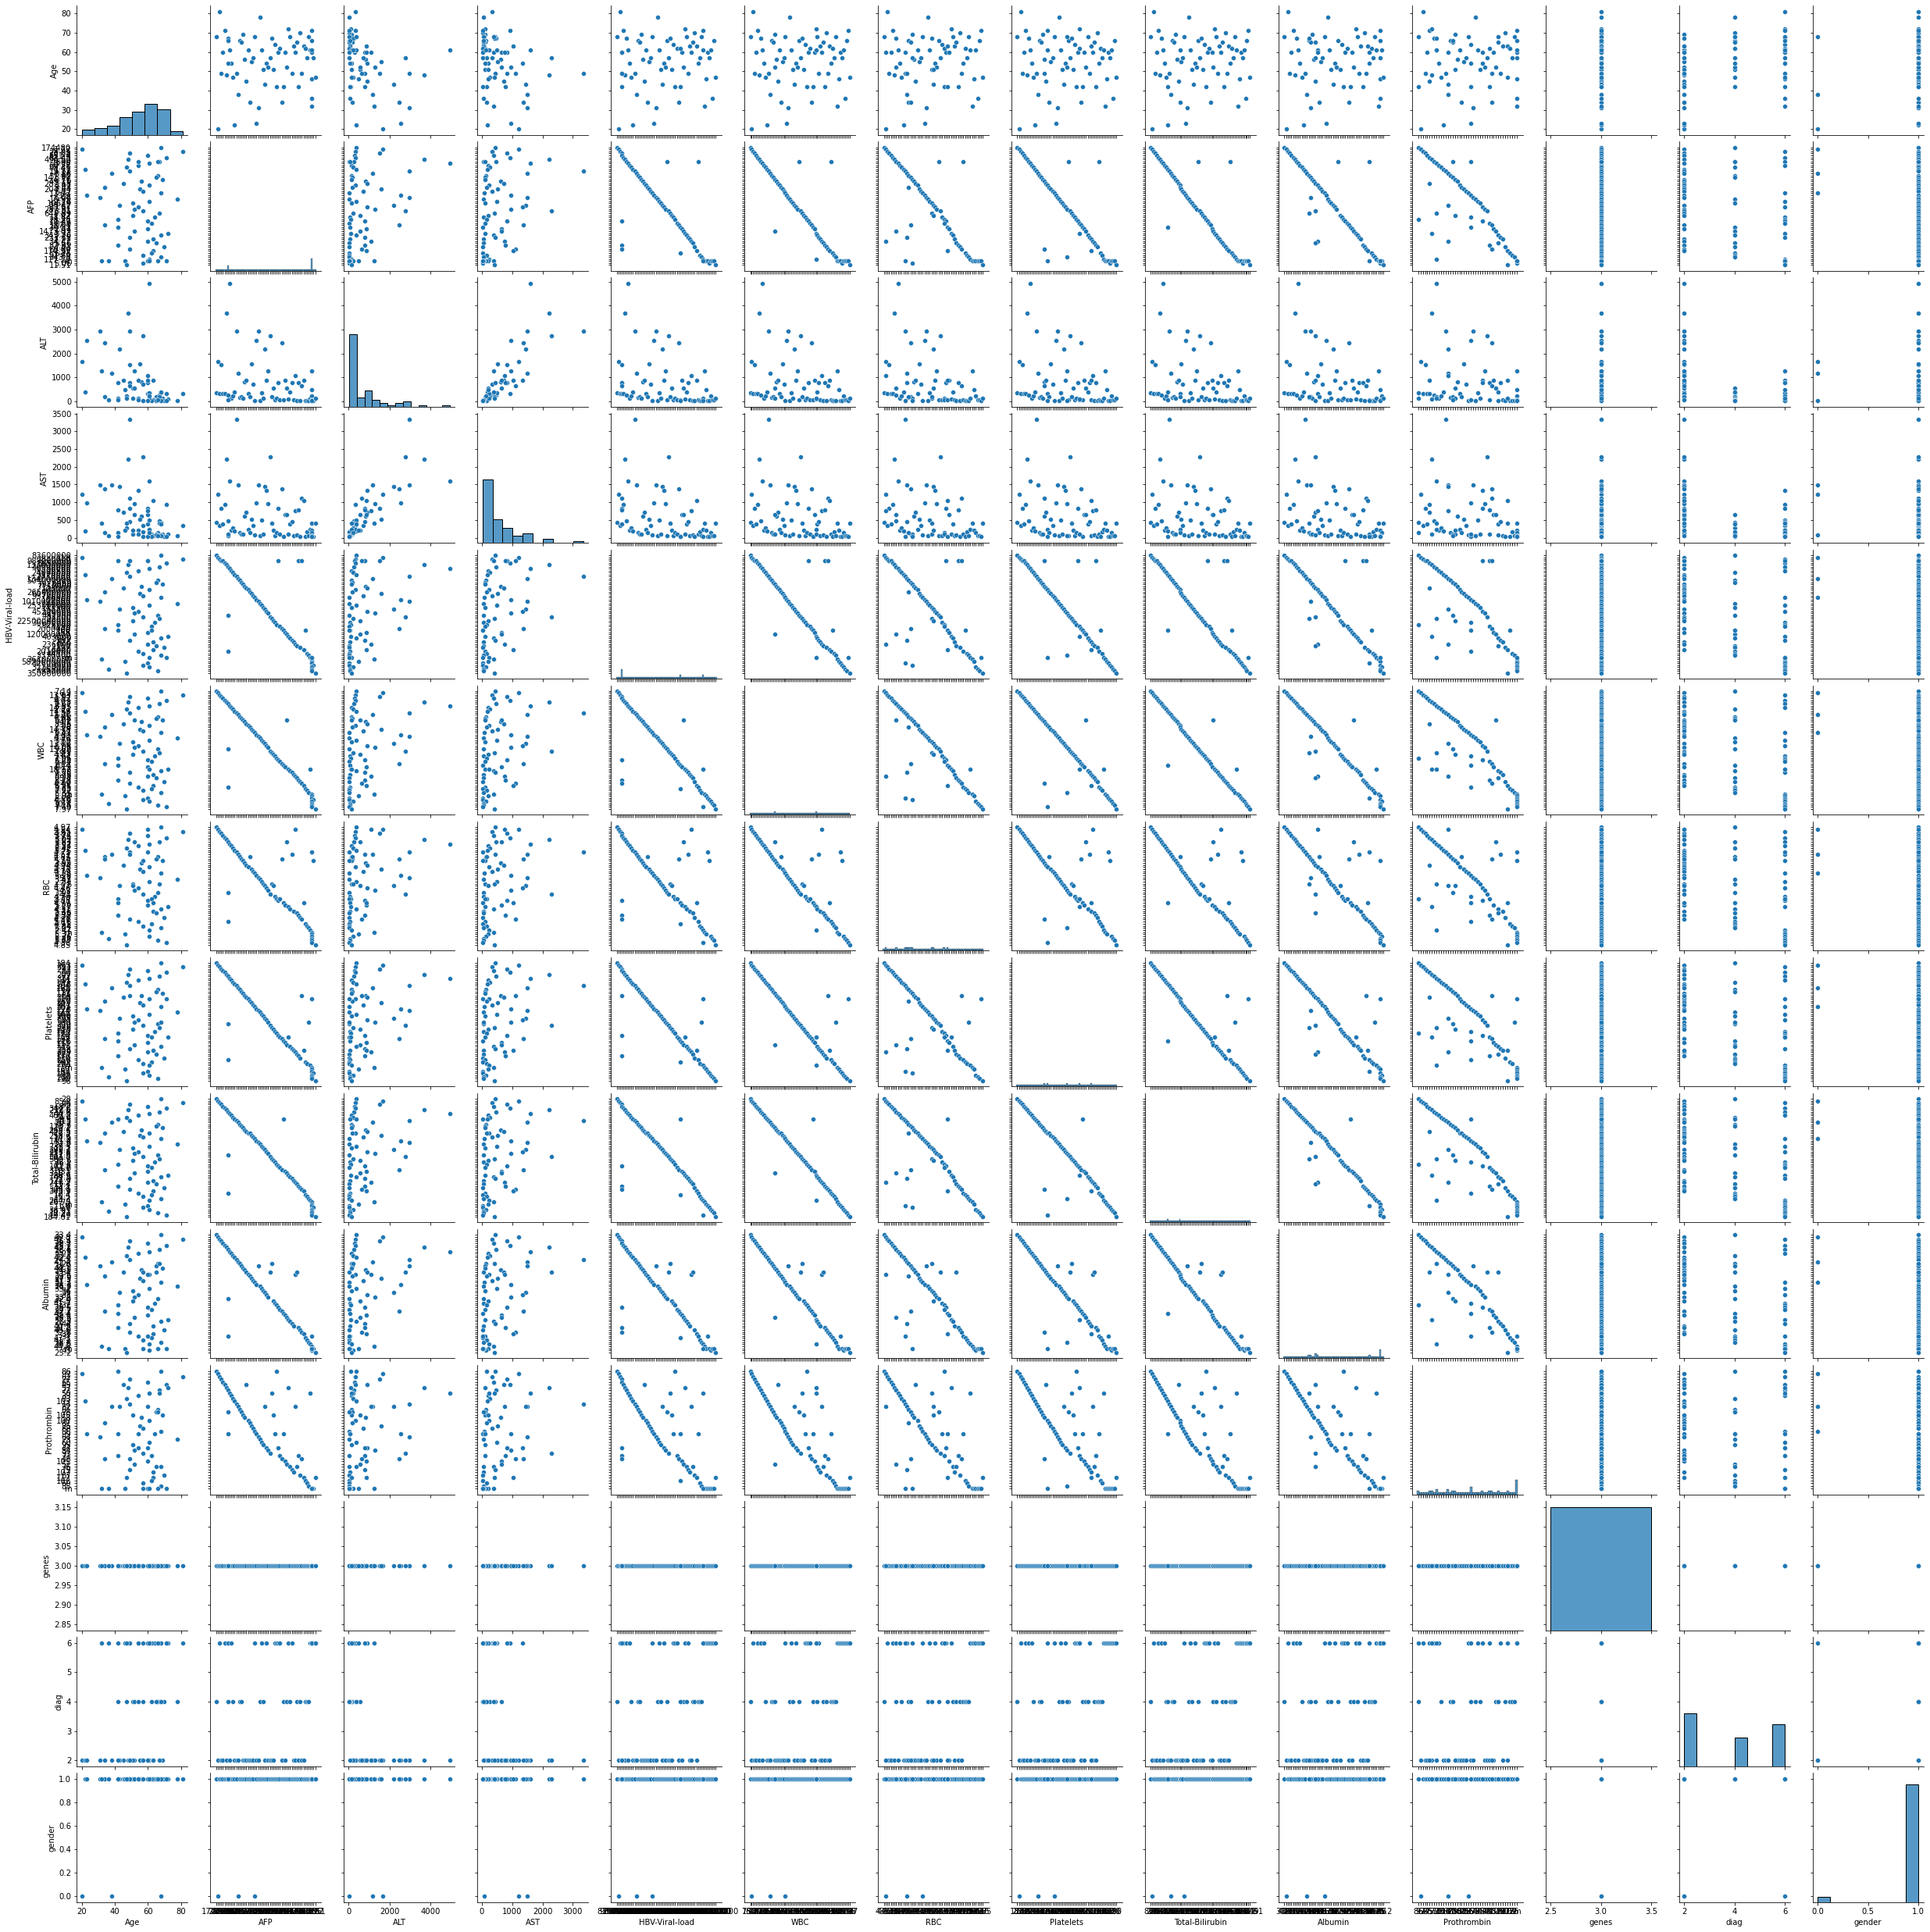

In [95]:
sns.pairplot(data=df1,vars=['Age','AFP','ALT','AST','HBV-Viral-load','WBC','RBC','Platelets','Total-Bilirubin','Albumin','Prothrombin','genes','diag','gender'])

In [96]:
from matplotlib import pyplot as plt

In [97]:
dfg = data.groupby(['Gender', 'Age']).size().reset_index()
dfg['Gender'].value_counts()

Male      70
Female    65
Name: Gender, dtype: int64

In [98]:
dfg.head()

,Gender,Age,0
0,Female,16.0,1
1,Female,17.0,2
2,Female,18.0,3
3,Female,19.0,10
4,Female,20.0,2


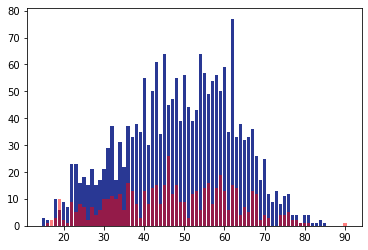

In [99]:
p1 = plt.bar(dfg.loc[dfg['Gender'] == 'Male']['Age']
             ,dfg.loc[dfg['Gender'] == 'Male'][0]
             ,alpha=0.9,color='#128')

p1 = plt.bar(dfg.loc[dfg['Gender'] == 'Female']['Age']
             ,dfg.loc[dfg['Gender'] == 'Female'][0]
            , alpha=0.5,color='red')

In [100]:
dfg.loc[dfg['Gender'] == 'Male']['Age']
dfg.loc[dfg['Gender'] == 'Male'][0]

65     15.0
66     16.0
67     18.0
68     19.0
69     20.0
       ... 
130    81.0
131    82.0
132    83.0
133    84.0
134    85.0
Name: Age, Length: 70, dtype: float64

65      3
66      2
67     10
68      6
69      9
       ..
130     4
131     1
132     1
133     2
134     1
Name: 0, Length: 70, dtype: int64

In [68]:
#pd.read_excel('HBV_pool_data.xlsx')

,Diagnosis,Patient ID,Age,Gender,HBeAg,AntiHBe,HBV- Viral load,AFP,WBC,RBC,...,APRI,hbvdna,inr,na,glu,ure,crea,nh3,fibroscan,gpb
0,HCC,Di_hcc45,57.0,male,neg,neg,239000,1.76,6.89,4.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HCC,Di_hcc47,50.0,male,neg,neg,37200000,14.88,6.16,5.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HCC,Di_hcc55,57.0,male,NaN,NaN,4310000,160,5.74,4.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HCC,Di_hcc57,53.0,male,NaN,NaN,NaN,300,8.33,3.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HCC,Di_hcc58,61.0,male,neg,pos,81700,160,7.27,3.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4398,LC,LC 49,61.0,Male,m,m,32100000,m,5.19,5.36,...,4.085366,32100000,m,137,4.86,4.9,67.0,m,F4,NaN
4399,LC,LC 51,36.0,Male,m,m,253000,m,10.3,5.56,...,0.608696,253000,m,m,5.35,3.7,70.0,m,F4,NaN
4400,LC,LC 54,66.0,Male,pos,m,4990000,m,7.16,5.67,...,0.697368,4990000,m,m,6.24,6.9,97.0,m,NaN,NaN
4401,LC,XG 2,71.0,Male,m,m,m,m,7.48,4.36,...,NaN,m,m,m,8.97,5.8,101.0,m,F3-F4,NaN


In [69]:
#df1.to_excel("HBV_label_encoded.xlsx", sheet_name="Biochemical", index=False)